In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from MultiOutXGBRegressor import OptunaTuneMultioutXGBRegressorCV,FitFinalMultioutXGBRegressor,predict,save_model,load_model
from OneShotSamplesGenerator import gen_one_out_samples
from captum.attr import IntegratedGradients
from captum.attr import visualization as viz
import pandas as pd
import numpy as np
import os
import calendar
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.templates.default = 'plotly_white'
plot_template = dict(
    layout=go.Layout({
        'font_size': 8,
        'xaxis_title_font_size': 8,
        'yaxis_title_font_size': 8,
        }   
))
hydro_stations = [
    'Guide',
    'Xunhua'
]
start_date = '1957-01-01'
end_date = '2019-12-31'
nfolds = 5
n_trials = 100 #200
num_boost_round = 50 #100
n_warmup_steps = 20
from metrics import PPMAE,LPMAE
import HydroErr as he

Build CER(XGBoost) model and estimate natural flow during 1986-2019


In [2]:
for hydro_station in hydro_stations:
    df = pd.read_csv(f'../data/{hydro_station.lower()}_vif_modeling_data_1960-2019.csv',parse_dates=['date'],index_col='date')
    # select data before 1986
    df_ = df.loc[:'1986-01-01']
    
    samples,target,features = gen_one_out_samples(df,target_column='flow',mode='simulate',lags_dict=None,lag=12,lead=1)
    samples.to_csv(f'../samples/{hydro_station.lower()}_samples.csv')

    feature_samples = samples[features]
    feature_samples_ = feature_samples.loc[:'1986-01-01']

    target_samples = pd.DataFrame(samples[target],columns=[target])
    target_samples_ = target_samples.loc[:'1986-01-01']

    features = feature_samples.columns
    target = target_samples.columns

    spring_samples = samples[samples.index.month.isin([3,4,5])]
    summer_samples = samples[samples.index.month.isin([6,7,8])]
    autumn_samples = samples[samples.index.month.isin([9,10,11])]
    winter_samples = samples[samples.index.month.isin([12,1,2])]
    
    spring_features_samples = spring_samples[features]
    summer_features_samples = summer_samples[features]
    autumn_features_samples = autumn_samples[features]
    winter_features_samples = winter_samples[features]

    spring_target_samples = spring_samples[target]
    summer_target_samples = summer_samples[target]
    autumn_target_samples = autumn_samples[target]
    winter_target_samples = winter_samples[target]

    model_path = f'../models/CER/{hydro_station.lower()}/XGBOOST_lag12/'
    if not os.path.exists(model_path):
        os.makedirs(model_path)
    if not os.path.exists(model_path+f'vif_xgb_model.json'):
        best_params = OptunaTuneMultioutXGBRegressorCV(
                train_X=feature_samples_,
                train_Y=target_samples_,
                nfolds=nfolds,
                n_trials=n_trials,#200
                num_boost_round=num_boost_round,#100
            n_warmup_steps=n_warmup_steps
        )   
        print(best_params)
        model = FitFinalMultioutXGBRegressor(feature_samples_,target_samples_,best_params,100)
        save_model(model,model_path+f'vif_xgb_model.json')

        # train seasonal models
        best_params_spring = OptunaTuneMultioutXGBRegressorCV(
            train_X=spring_features_samples,
            train_Y=spring_target_samples,
            nfolds=nfolds,
            n_trials=n_trials,
            num_boost_round=num_boost_round,
            n_warmup_steps=n_warmup_steps
        )
        model_spring = FitFinalMultioutXGBRegressor(spring_features_samples,spring_target_samples,best_params_spring,100)
        save_model(model_spring,model_path+f'spring_vif_xgb_model.json')

        best_params_summer = OptunaTuneMultioutXGBRegressorCV(
            train_X=summer_features_samples,
            train_Y=summer_target_samples,
            nfolds=nfolds,
            n_trials=n_trials,
            num_boost_round=num_boost_round,
            n_warmup_steps=n_warmup_steps
        )
        model_summer = FitFinalMultioutXGBRegressor(summer_features_samples,summer_target_samples,best_params_summer,100)
        save_model(model_summer,model_path+f'summer_vif_xgb_model.json')

        best_params_autumn = OptunaTuneMultioutXGBRegressorCV(
            train_X=autumn_features_samples,
            train_Y=autumn_target_samples,
            nfolds=nfolds,
            n_trials=n_trials,
            num_boost_round=num_boost_round,
            n_warmup_steps=n_warmup_steps
        )
        model_autumn = FitFinalMultioutXGBRegressor(autumn_features_samples,autumn_target_samples,best_params_autumn,100)
        save_model(model_autumn,model_path+f'autumn_vif_xgb_model.json')

        best_params_winter = OptunaTuneMultioutXGBRegressorCV(
            train_X=winter_features_samples,
            train_Y=winter_target_samples,
            nfolds=nfolds,
            n_trials=n_trials,
            num_boost_round=num_boost_round,
            n_warmup_steps=n_warmup_steps
        )
        model_winter = FitFinalMultioutXGBRegressor(winter_features_samples,winter_target_samples,best_params_winter,100)
        save_model(model_winter,model_path+f'winter_vif_xgb_model.json')
        

    else:
        model = load_model(model_path+f'vif_xgb_model.json')
    pred = predict(model,feature_samples)
    
    pred_df = pd.DataFrame(pred,columns=['CER-XGB'],index=target_samples.index)
    pred_df.index.name = 'date'
    pred_df.to_csv(f'../results/vif_xgb_{hydro_station.lower()}.csv')

Evalueate the performance of CER(XGBoost) model

In [3]:
for hydro_station in hydro_stations:
    df = pd.read_csv(f'../results/vif_xgb_{hydro_station.lower()}.csv',parse_dates=['date'],index_col='date')
    flow = pd.read_csv(f'../data/{hydro_station.lower()}_vif_modeling_data_1960-2019.csv',parse_dates=['date'],index_col='date')


    cal_pred = df.loc['1961-01-01':'1981-12-31','CER-XGB'].values
    cal_obs = flow.loc['1961-01-01':'1981-12-31','flow'].values

    # print(cal_pred.shape)
    # print(cal_obs.shape)
    
    # plt.plot(cal_obs)
    # plt.plot(cal_pred)
    # plt.show()

    test_pred = df.loc['1982-01-01':'1985-12-31','CER-XGB'].values
    test_obs = flow.loc['1982-01-01':'1985-12-31','flow'].values

    metrics = pd.DataFrame(index=['cal','test'])
    metrics.index.name = 'period'
    metrics['ME'] = [he.me(observed_array=cal_obs, simulated_array=cal_pred),he.me(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MAE'] = [he.mae(observed_array=cal_obs, simulated_array=cal_pred),he.mae(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MSE'] = [he.mse(observed_array=cal_obs, simulated_array=cal_pred),he.mse(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MLE'] = [he.mle(observed_array=cal_obs, simulated_array=cal_pred),he.mle(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MALE'] = [he.male(observed_array=cal_obs, simulated_array=cal_pred),he.male(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MSLE'] = [he.msle(observed_array=cal_obs, simulated_array=cal_pred),he.msle(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MAPE'] = [he.mape(observed_array=cal_obs, simulated_array=cal_pred),he.mape(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MDE'] = [he.mde(observed_array=cal_obs, simulated_array=cal_pred),he.mde(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MDAE'] = [he.mdae(observed_array=cal_obs, simulated_array=cal_pred),he.mdae(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MDSE'] = [he.mdse(observed_array=cal_obs, simulated_array=cal_pred),he.mdse(observed_array=test_obs, simulated_array=test_pred),]
    metrics['ED'] = [he.ed(observed_array=cal_obs, simulated_array=cal_pred),he.ed(observed_array=test_obs, simulated_array=test_pred),]
    metrics['NED'] = [he.ned(observed_array=cal_obs, simulated_array=cal_pred),he.ned(observed_array=test_obs, simulated_array=test_pred),]
    metrics['RMSE'] = [he.rmse(observed_array=cal_obs, simulated_array=cal_pred), he.rmse(observed_array=test_obs, simulated_array=test_pred),]
    metrics['RMSLE'] = [he.rmsle(observed_array=cal_obs, simulated_array=cal_pred), he.rmsle(observed_array=test_obs, simulated_array=test_pred),]
    metrics['NRMSE_RANGE'] = [he.nrmse_range(observed_array=cal_obs, simulated_array=cal_pred), he.nrmse_range(observed_array=test_obs, simulated_array=test_pred),]
    metrics['NRMSE_MEAN'] = [he.nrmse_mean(observed_array=cal_obs, simulated_array=cal_pred), he.nrmse_mean(observed_array=test_obs, simulated_array=test_pred),]
    metrics['NRMSE_IQR'] = [he.nrmse_iqr(observed_array=cal_obs, simulated_array=cal_pred), he.nrmse_iqr(observed_array=test_obs, simulated_array=test_pred),]
    metrics['IRMSE'] = [he.irmse(observed_array=cal_obs, simulated_array=cal_pred), he.irmse(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MASE'] = [he.mase(observed_array=cal_obs, simulated_array=cal_pred), he.mase(observed_array=test_obs, simulated_array=test_pred),]
    metrics['R_SQUARED'] = [he.r_squared(observed_array=cal_obs, simulated_array=cal_pred), he.r_squared(observed_array=test_obs, simulated_array=test_pred),]
    metrics['PEARSON_R'] = [he.pearson_r(observed_array=cal_obs, simulated_array=cal_pred), he.pearson_r(observed_array=test_obs, simulated_array=test_pred),]
    metrics['SPEARMAN_R'] = [he.spearman_r(observed_array=cal_obs, simulated_array=cal_pred), he.spearman_r(observed_array=test_obs, simulated_array=test_pred),]
    metrics['ACC'] = [he.acc(observed_array=cal_obs, simulated_array=cal_pred), he.acc(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MAPE'] = [he.mape(observed_array=cal_obs, simulated_array=cal_pred), he.mape(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MAPD'] = [he.mapd(observed_array=cal_obs, simulated_array=cal_pred), he.mapd(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MAAPE'] = [he.maape(observed_array=cal_obs, simulated_array=cal_pred), he.maape(observed_array=test_obs, simulated_array=test_pred),]
    metrics['SMAPE1'] = [he.smape1(observed_array=cal_obs, simulated_array=cal_pred), he.smape1(observed_array=test_obs, simulated_array=test_pred),]
    metrics['SMAPE2'] = [he.smape2(observed_array=cal_obs, simulated_array=cal_pred), he.smape2(observed_array=test_obs, simulated_array=test_pred),]
    metrics['D'] = [he.d(observed_array=cal_obs, simulated_array=cal_pred), he.d(observed_array=test_obs, simulated_array=test_pred),]
    metrics['D1'] = [he.d1(observed_array=cal_obs, simulated_array=cal_pred), he.d1(observed_array=test_obs, simulated_array=test_pred),]
    metrics['DMOD'] = [he.dmod(observed_array=cal_obs, simulated_array=cal_pred), he.dmod(observed_array=test_obs, simulated_array=test_pred),]
    metrics['DREL'] = [he.drel(observed_array=cal_obs, simulated_array=cal_pred), he.drel(observed_array=test_obs, simulated_array=test_pred),]
    metrics['DR'] = [he.dr(observed_array=cal_obs, simulated_array=cal_pred), he.dr(observed_array=test_obs, simulated_array=test_pred),]
    metrics['WATT_M'] = [he.watt_m(observed_array=cal_obs, simulated_array=cal_pred), he.watt_m(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MB_R'] = [he.mb_r(observed_array=cal_obs, simulated_array=cal_pred), he.mb_r(observed_array=test_obs, simulated_array=test_pred),]
    metrics['NSE'] = [he.nse(observed_array=cal_obs, simulated_array=cal_pred), he.nse(observed_array=test_obs, simulated_array=test_pred),]
    metrics['NSE_MOD'] = [he.nse_mod(observed_array=cal_obs, simulated_array=cal_pred), he.nse_mod(observed_array=test_obs, simulated_array=test_pred),]
    metrics['NSE_REL'] = [he.nse_rel(observed_array=cal_obs, simulated_array=cal_pred), he.nse_rel(observed_array=test_obs, simulated_array=test_pred),]
    metrics['KGE_2009'] = [he.kge_2009(observed_array=cal_obs, simulated_array=cal_pred),he.kge_2009(observed_array=test_obs, simulated_array=test_pred),]
    metrics['KGE_2012'] = [he.kge_2012(observed_array=cal_obs, simulated_array=cal_pred),he.kge_2012(observed_array=test_obs, simulated_array=test_pred),]
    metrics['LM_INDEX'] = [he.lm_index(observed_array=cal_obs, simulated_array=cal_pred),he.lm_index(observed_array=test_obs, simulated_array=test_pred),]
    metrics['D1_P'] = [he.d1_p(observed_array=cal_obs, simulated_array=cal_pred),he.d1_p(observed_array=test_obs, simulated_array=test_pred),]
    metrics['VE'] = [he.ve(observed_array=cal_obs, simulated_array=cal_pred),he.ve(observed_array=test_obs, simulated_array=test_pred),]
    metrics['SA'] = [he.sa(observed_array=cal_obs, simulated_array=cal_pred),he.sa(observed_array=test_obs, simulated_array=test_pred),]
    metrics['SC'] = [he.sc(observed_array=cal_obs, simulated_array=cal_pred),he.sc(observed_array=test_obs, simulated_array=test_pred),]
    metrics['SID'] = [he.sid(observed_array=cal_obs, simulated_array=cal_pred),he.sid(observed_array=test_obs, simulated_array=test_pred),]
    metrics['SGA'] = [he.sga(observed_array=cal_obs, simulated_array=cal_pred),he.sga(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H1_MHE'] = [he.h1_mhe(observed_array=cal_obs, simulated_array=cal_pred),he.h1_mhe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H1_MAHE'] = [he.h1_mahe(observed_array=cal_obs, simulated_array=cal_pred),he.h1_mahe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H1_RMSHE'] = [he.h1_rmshe(observed_array=cal_obs, simulated_array=cal_pred),he.h1_rmshe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H2_MHE'] = [he.h2_mhe(observed_array=cal_obs, simulated_array=cal_pred),he.h2_mhe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H2_MAHE'] = [he.h2_mahe(observed_array=cal_obs, simulated_array=cal_pred),he.h2_mahe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H2_RMSHE'] = [he.h2_rmshe(observed_array=cal_obs, simulated_array=cal_pred),he.h2_rmshe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H3_MHE'] = [he.h3_mhe(observed_array=cal_obs, simulated_array=cal_pred),he.h3_mhe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H3_MAHE'] = [he.h3_mahe(observed_array=cal_obs, simulated_array=cal_pred),he.h3_mahe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H3_RMSHE'] = [he.h3_rmshe(observed_array=cal_obs, simulated_array=cal_pred),he.h3_rmshe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H4_MHE'] = [he.h4_mhe(observed_array=cal_obs, simulated_array=cal_pred),he.h4_mhe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H4_MAHE'] = [he.h4_mahe(observed_array=cal_obs, simulated_array=cal_pred),he.h4_mahe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H4_RMSHE'] = [he.h4_rmshe(observed_array=cal_obs, simulated_array=cal_pred),he.h4_rmshe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H5_MHE'] = [he.h5_mhe(observed_array=cal_obs, simulated_array=cal_pred),he.h5_mhe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H5_MAHE'] = [he.h5_mahe(observed_array=cal_obs, simulated_array=cal_pred),he.h5_mahe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H5_RMSHE'] = [he.h5_rmshe(observed_array=cal_obs, simulated_array=cal_pred),he.h5_rmshe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H6_MHE'] = [he.h6_mhe(observed_array=cal_obs, simulated_array=cal_pred),he.h6_mhe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H6_MAHE'] = [he.h6_mahe(observed_array=cal_obs, simulated_array=cal_pred),he.h6_mahe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H6_RMSHE'] = [he.h6_rmshe(observed_array=cal_obs, simulated_array=cal_pred),he.h6_rmshe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H7_MHE'] = [he.h7_mhe(observed_array=cal_obs, simulated_array=cal_pred),he.h7_mhe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H7_MAHE'] = [he.h7_mahe(observed_array=cal_obs, simulated_array=cal_pred),he.h7_mahe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H7_RMSHE'] = [he.h7_rmshe(observed_array=cal_obs, simulated_array=cal_pred),he.h7_rmshe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H8_MHE'] = [he.h8_mhe(observed_array=cal_obs, simulated_array=cal_pred),he.h8_mhe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H8_MAHE'] = [he.h8_mahe(observed_array=cal_obs, simulated_array=cal_pred),he.h8_mahe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H8_RMSHE'] = [he.h8_rmshe(observed_array=cal_obs, simulated_array=cal_pred),he.h8_rmshe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H10_MHE'] = [he.h10_mhe(observed_array=cal_obs, simulated_array=cal_pred),he.h10_mhe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H10_MAHE'] = [he.h10_mahe(observed_array=cal_obs, simulated_array=cal_pred),he.h10_mahe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H10_RMSHE'] = [he.h10_rmshe(observed_array=cal_obs, simulated_array=cal_pred),he.h10_rmshe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['G_MEAN_DIFF'] = [he.g_mean_diff(observed_array=cal_obs, simulated_array=cal_pred),he.g_mean_diff(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MEAN_VAR'] = [he.mean_var(observed_array=cal_obs, simulated_array=cal_pred),he.mean_var(observed_array=test_obs, simulated_array=test_pred),]
    metrics['PPMAE'] = [PPMAE(y_true=cal_obs,y_pred=cal_pred),PPMAE(y_true=test_obs,y_pred=test_pred),]
    metrics['LPMAE'] = [LPMAE(y_true=cal_obs,y_pred=cal_pred),LPMAE(y_true=test_obs,y_pred=test_pred),]

    metrics.to_csv(f'../results/vif_xgb_metrics_{hydro_station.lower()}.csv')
    print(hydro_station,'\n',metrics)


Guide 
               ME       MAE         MSE      MLE      MALE      MSLE      MAPE  \
period                                                                          
cal    -0.385969  4.615574  883.914491  0.00086  0.003936  0.000127  0.392457   
test    0.056490  2.512305   25.112662 -0.00118  0.002910  0.000040  0.289999   

             MDE      MDAE      MDSE  ...    H8_MHE   H8_MAHE  H8_RMSHE  \
period                                ...                                 
cal     0.068856  0.662890  0.439435  ...  0.000868  0.003683  0.010225   
test   -0.113773  0.740718  0.550529  ... -0.001153  0.002873  0.006204   

        H10_MHE  H10_MAHE  H10_RMSHE  G_MEAN_DIFF  MEAN_VAR      PPMAE  \
period                                                                   
cal     0.00086  0.003936   0.011289     1.000904  0.000127  46.306135   
test   -0.00118  0.002910   0.006342     0.998655  0.000039   3.321501   

           LPMAE  
period            
cal     0.504094  
test    0.35

C:\Users\ZJY\AppData\Local\Temp\ipykernel_180816\4034516173.py:99: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(list(feature_groups.keys()), fontsize=8, rotation=45)
C:\Users\ZJY\AppData\Local\Temp\ipykernel_180816\4034516173.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticks(), fontsize=8)
C:\Users\ZJY\AppData\Local\Temp\ipykernel_180816\4034516173.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Attribution Values', y='Predictors', data=global_importance,
C:\Users\ZJY\AppData\Local\Temp\ipykernel_180816\4034516173.py:133: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e.

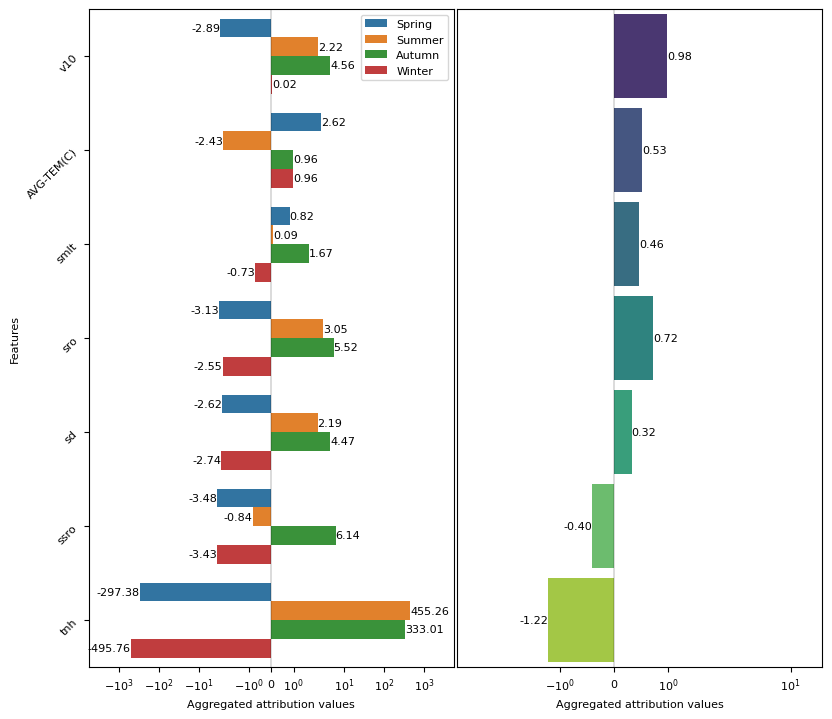

C:\Users\ZJY\AppData\Local\Temp\ipykernel_180816\4034516173.py:99: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(list(feature_groups.keys()), fontsize=8, rotation=45)
C:\Users\ZJY\AppData\Local\Temp\ipykernel_180816\4034516173.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticks(), fontsize=8)
C:\Users\ZJY\AppData\Local\Temp\ipykernel_180816\4034516173.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Attribution Values', y='Predictors', data=global_importance,
C:\Users\ZJY\AppData\Local\Temp\ipykernel_180816\4034516173.py:133: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e.

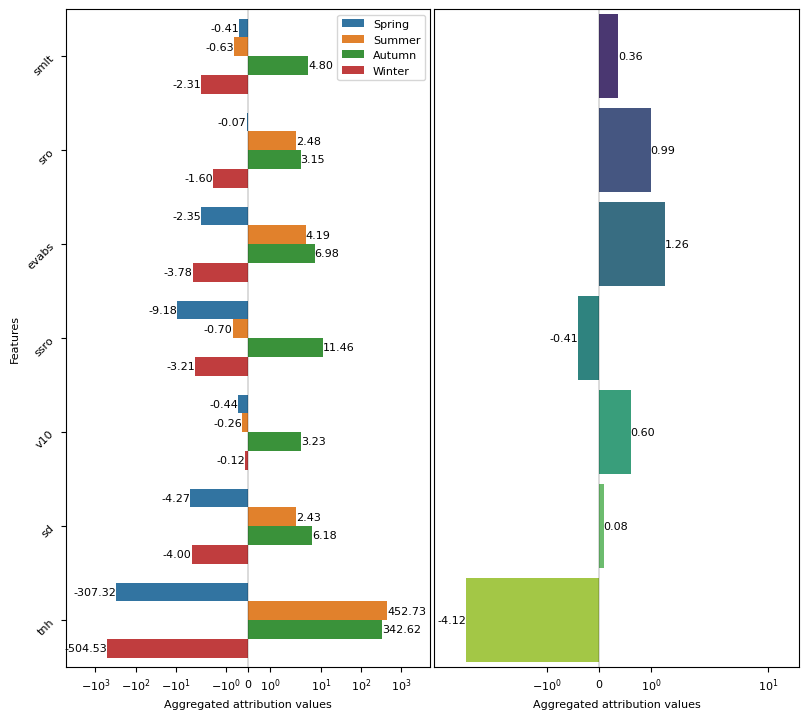

In [4]:
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

for hydro_station in hydro_stations:
    df = pd.read_csv(f'../data/{hydro_station.lower()}_vif_modeling_data_1960-2019.csv',parse_dates=['date'],index_col='date')
    
    samples,target,features = gen_one_out_samples(df,target_column='flow',mode='simulate',lags_dict=None,lag=12,lead=1)
    samples.to_csv(f'../samples/{hydro_station.lower()}_samples.csv')

    feature_samples = samples[features]
    feature_samples_ = feature_samples.loc[:'1986-01-01']

    target_samples = pd.DataFrame(samples[target],columns=[target])
    target_samples_ = target_samples.loc[:'1986-01-01']

    # Split features and target samples by season
    spring_feature_samples = feature_samples_[feature_samples_.index.month.isin([3,4,5])]
    summer_feature_samples = feature_samples_[feature_samples_.index.month.isin([6,7,8])]
    autumn_feature_samples = feature_samples_[feature_samples_.index.month.isin([9,10,11])]
    winter_feature_samples = feature_samples_[feature_samples_.index.month.isin([12,1,2])]

    spring_target_samples = target_samples_[target_samples_.index.month.isin([3,4,5])]
    summer_target_samples = target_samples_[target_samples_.index.month.isin([6,7,8])]
    autumn_target_samples = target_samples_[target_samples_.index.month.isin([9,10,11])]
    winter_target_samples = target_samples_[target_samples_.index.month.isin([12,1,2])]

    # Load trained XGBoost model
    model_path = f'../models/CER/{hydro_station.lower()}/XGBOOST_lag12/'
    model = load_model(model_path+f'vif_xgb_model.json')

    # Calculate SHAP values for each season
    explainer = shap.TreeExplainer(model)
    
    spring_shap_values = explainer.shap_values(spring_feature_samples)
    summer_shap_values = explainer.shap_values(summer_feature_samples)
    autumn_shap_values = explainer.shap_values(autumn_feature_samples)
    winter_shap_values = explainer.shap_values(winter_feature_samples)
    
    # Calculate global SHAP values
    global_shap_values = explainer.shap_values(feature_samples_)

    # Group features by predictor
    feature_groups = {}
    for feature in features:
        predictor = feature.split('_')[0]  # Get predictor name before underscore
        if predictor not in feature_groups:
            feature_groups[predictor] = []
        feature_groups[predictor].append(feature)

    # Calculate seasonal contributions for grouped features
    seasonal_contributions = {
        'Spring': {},
        'Summer': {},
        'Autumn': {},
        'Winter': {}
    }

    for predictor, predictor_features in feature_groups.items():
        feature_indices = [features.index(f) for f in predictor_features]
        
        seasonal_contributions['Spring'][predictor] = np.mean(spring_shap_values[:, feature_indices].sum(axis=1))
        seasonal_contributions['Summer'][predictor] = np.mean(summer_shap_values[:, feature_indices].sum(axis=1))
        seasonal_contributions['Autumn'][predictor] = np.mean(autumn_shap_values[:, feature_indices].sum(axis=1))
        seasonal_contributions['Winter'][predictor] = np.mean(winter_shap_values[:, feature_indices].sum(axis=1))

    # Create seasonal DataFrame with grouped features
    seasonal_df = pd.DataFrame(seasonal_contributions).reset_index()
    seasonal_df.columns = ['Predictor', 'Spring', 'Summer', 'Autumn', 'Winter']
    seasonal_df = seasonal_df.melt(id_vars='Predictor', var_name='Season', value_name='Contribution')

    # Calculate global contributions for grouped features
    global_contributions = {}
    for predictor, predictor_features in feature_groups.items():
        feature_indices = [features.index(f) for f in predictor_features]
        global_contributions[predictor] = np.mean(global_shap_values[:, feature_indices].sum(axis=1))

    # Create visualization
    ftsize = 8
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.48, 7))
    
    # Plot seasonal contributions
    sns.barplot(x='Contribution', y='Predictor', hue='Season', data=seasonal_df, orient='h', ax=ax1)
    
    # Add value labels
    for p in ax1.patches:
        width = p.get_width()
        if abs(width) < 0.001:
            continue
        offset = 0.02 if abs(width) < 0.1 else 0.2
        ha = 'left' if width >= 0 else 'right'
        ax1.text(width, p.get_y() + p.get_height()/2, f'{width:.2f}', 
                ha=ha, va='center', fontsize=8)

    ax1.set_xlim(seasonal_df['Contribution'].min()-5000, seasonal_df['Contribution'].max()+5000)
    ax1.axvline(x=0.0, color='black', linestyle='-', linewidth=0.2)
    ax1.set_ylabel('Features', fontsize=ftsize)
    ax1.set_yticklabels(list(feature_groups.keys()), fontsize=8, rotation=45)
    ax1.set_xlabel('Aggregated attribution values', fontsize=ftsize)
    ax1.set_xticklabels(ax1.get_xticks(), fontsize=8)
    ax1.set_xscale('symlog')
    # ax1.set_title(f'(a) Local interpretation for {hydro_station.capitalize()}', fontsize=ftsize)

    ax1.legend(loc='upper right',fontsize=ftsize)

    # Plot global contributions
    global_importance = pd.DataFrame({
        'Predictors': list(feature_groups.keys()),
        'Attribution Values': list(global_contributions.values())
    })
    
    sns.barplot(x='Attribution Values', y='Predictors', data=global_importance, 
                orient='h', palette='viridis', width=0.9, ax=ax2)

    # Add value labels
    for p in ax2.patches:
        width = p.get_width()
        if abs(width) < 0.001:
            continue
        offset = 0.02 if abs(width) < 0.1 else 0.2
        ha = 'left' if width >= 0 else 'right'
        ax2.text(width, p.get_y() + p.get_height()/2, f'{width:.2f}',
                ha=ha, va='center', fontsize=8)

    ax2.set_xlim(global_importance['Attribution Values'].min()-5.0, 
                 global_importance['Attribution Values'].max()+20)
    ax2.axvline(x=0.0, color='black', linestyle='-', linewidth=0.2)
    ax2.set_yticklabels([])
    ax2.yaxis.set_ticks([])
    ax2.set_ylabel('')
    ax2.set_xlabel('Aggregated attribution values', fontsize=ftsize)
    ax2.set_xticklabels(ax2.get_xticks(), fontsize=8)
    ax2.set_xscale('symlog')
    # ax2.set_title(f'(b) Global interpretation for {hydro_station.capitalize()}', fontsize=ftsize)

    

    fig.subplots_adjust(left=0.01, bottom=0.05, right=0.99, top=0.99, hspace=0.05, wspace=0.01)
    plt.savefig(f'../figs/{hydro_station.lower()}_features_contributions_SHAP.eps', 
                format='EPS', dpi=2000, bbox_inches='tight')
    plt.savefig(f'../figs/{hydro_station.lower()}_features_contributions_SHAP.png',
                format='PNG', dpi=600, bbox_inches='tight')
    plt.show()




The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


{'v10': ['v10_{t-11}', 'v10_{t-10}', 'v10_{t-9}', 'v10_{t-8}', 'v10_{t-7}', 'v10_{t-6}', 'v10_{t-5}', 'v10_{t-4}', 'v10_{t-3}', 'v10_{t-2}', 'v10_{t-1}', 'v10_{t}', 'v10_{t+1}'], 'AVG-TEM(C)': ['AVG-TEM(C)_{t-11}', 'AVG-TEM(C)_{t-10}', 'AVG-TEM(C)_{t-9}', 'AVG-TEM(C)_{t-8}', 'AVG-TEM(C)_{t-7}', 'AVG-TEM(C)_{t-6}', 'AVG-TEM(C)_{t-5}', 'AVG-TEM(C)_{t-4}', 'AVG-TEM(C)_{t-3}', 'AVG-TEM(C)_{t-2}', 'AVG-TEM(C)_{t-1}', 'AVG-TEM(C)_{t}', 'AVG-TEM(C)_{t+1}'], 'smlt': ['smlt_{t-11}', 'smlt_{t-10}', 'smlt_{t-9}', 'smlt_{t-8}', 'smlt_{t-7}', 'smlt_{t-6}', 'smlt_{t-5}', 'smlt_{t-4}', 'smlt_{t-3}', 'smlt_{t-2}', 'smlt_{t-1}', 'smlt_{t}', 'smlt_{t+1}'], 'sro': ['sro_{t-11}', 'sro_{t-10}', 'sro_{t-9}', 'sro_{t-8}', 'sro_{t-7}', 'sro_{t-6}', 'sro_{t-5}', 'sro_{t-4}', 'sro_{t-3}', 'sro_{t-2}', 'sro_{t-1}', 'sro_{t}', 'sro_{t+1}'], 'sd': ['sd_{t-11}', 'sd_{t-10}', 'sd_{t-9}', 'sd_{t-8}', 'sd_{t-7}', 'sd_{t-6}', 'sd_{t-5}', 'sd_{t-4}', 'sd_{t-3}', 'sd_{t-2}', 'sd_{t-1}', 'sd_{t}', 'sd_{t+1}'], 'ssro': ['s

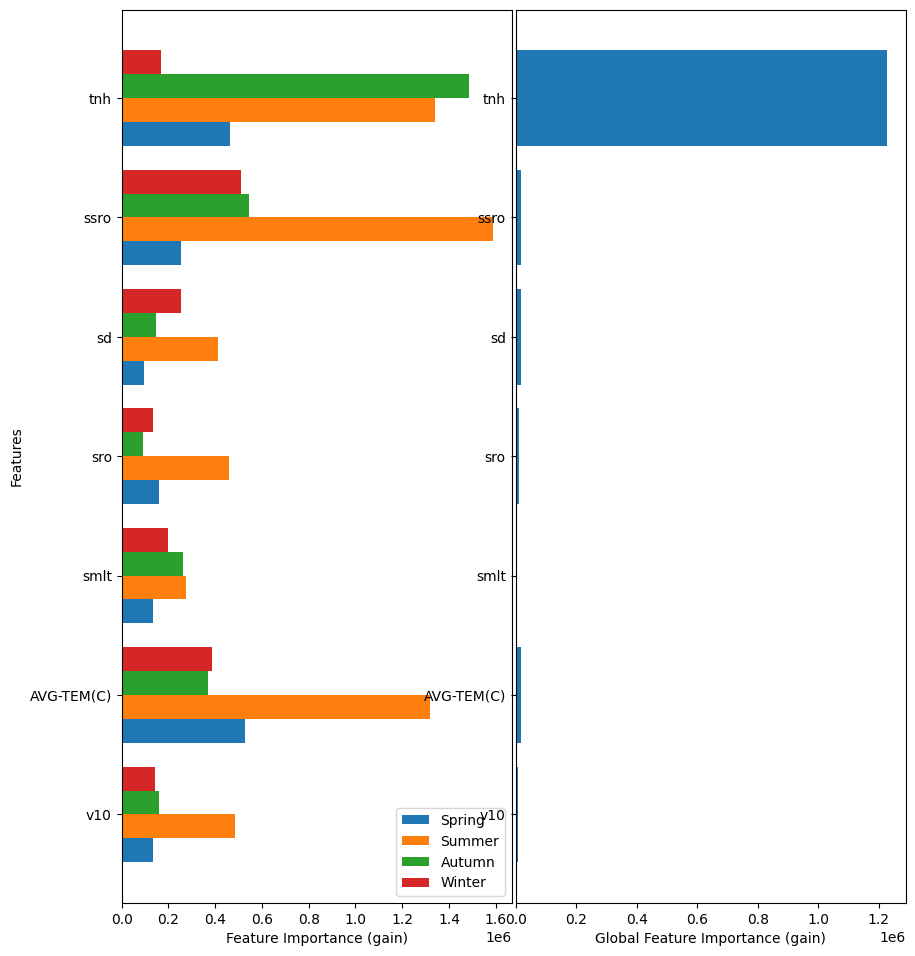

{'smlt': ['smlt_{t-11}', 'smlt_{t-10}', 'smlt_{t-9}', 'smlt_{t-8}', 'smlt_{t-7}', 'smlt_{t-6}', 'smlt_{t-5}', 'smlt_{t-4}', 'smlt_{t-3}', 'smlt_{t-2}', 'smlt_{t-1}', 'smlt_{t}', 'smlt_{t+1}'], 'sro': ['sro_{t-11}', 'sro_{t-10}', 'sro_{t-9}', 'sro_{t-8}', 'sro_{t-7}', 'sro_{t-6}', 'sro_{t-5}', 'sro_{t-4}', 'sro_{t-3}', 'sro_{t-2}', 'sro_{t-1}', 'sro_{t}', 'sro_{t+1}'], 'evabs': ['evabs_{t-11}', 'evabs_{t-10}', 'evabs_{t-9}', 'evabs_{t-8}', 'evabs_{t-7}', 'evabs_{t-6}', 'evabs_{t-5}', 'evabs_{t-4}', 'evabs_{t-3}', 'evabs_{t-2}', 'evabs_{t-1}', 'evabs_{t}', 'evabs_{t+1}'], 'ssro': ['ssro_{t-11}', 'ssro_{t-10}', 'ssro_{t-9}', 'ssro_{t-8}', 'ssro_{t-7}', 'ssro_{t-6}', 'ssro_{t-5}', 'ssro_{t-4}', 'ssro_{t-3}', 'ssro_{t-2}', 'ssro_{t-1}', 'ssro_{t}', 'ssro_{t+1}'], 'v10': ['v10_{t-11}', 'v10_{t-10}', 'v10_{t-9}', 'v10_{t-8}', 'v10_{t-7}', 'v10_{t-6}', 'v10_{t-5}', 'v10_{t-4}', 'v10_{t-3}', 'v10_{t-2}', 'v10_{t-1}', 'v10_{t}', 'v10_{t+1}'], 'sd': ['sd_{t-11}', 'sd_{t-10}', 'sd_{t-9}', 'sd_{t-8

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


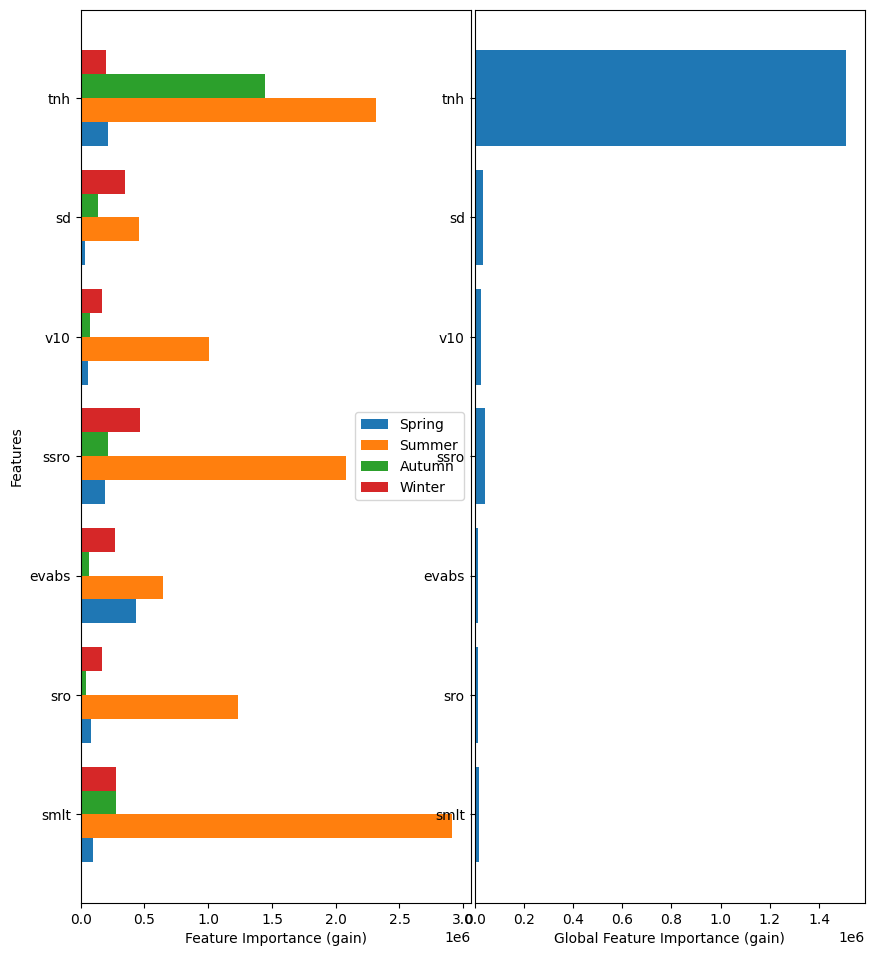

In [5]:
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

for hydro_station in hydro_stations:
    df = pd.read_csv(f'../data/{hydro_station.lower()}_vif_modeling_data_1960-2019.csv',parse_dates=['date'],index_col='date')
    
    samples,target,features = gen_one_out_samples(df,target_column='flow',mode='simulate',lags_dict=None,lag=12,lead=1)
    samples.to_csv(f'../samples/{hydro_station.lower()}_samples.csv')

    feature_samples = samples[features]
    feature_samples_ = feature_samples.loc[:'1986-01-01']

    target_samples = pd.DataFrame(samples[target],columns=[target])
    target_samples_ = target_samples.loc[:'1986-01-01']

    # Split features and target samples by season
    spring_feature_samples = feature_samples_[feature_samples_.index.month.isin([3,4,5])]
    summer_feature_samples = feature_samples_[feature_samples_.index.month.isin([6,7,8])]
    autumn_feature_samples = feature_samples_[feature_samples_.index.month.isin([9,10,11])]
    winter_feature_samples = feature_samples_[feature_samples_.index.month.isin([12,1,2])]

    spring_target_samples = target_samples_[target_samples_.index.month.isin([3,4,5])]
    summer_target_samples = target_samples_[target_samples_.index.month.isin([6,7,8])]
    autumn_target_samples = target_samples_[target_samples_.index.month.isin([9,10,11])]
    winter_target_samples = target_samples_[target_samples_.index.month.isin([12,1,2])]

    # Load trained XGBoost model
    model_path = f'../models/CER/{hydro_station.lower()}/XGBOOST_lag12/'
    model = load_model(model_path+f'vif_xgb_model.json')

    # Group features by base name (without lag)
    feature_groups = {}
    for feature in features:
        base_name = feature.split('_')[0]  # Get base name before lag
        if base_name not in feature_groups:
            feature_groups[base_name] = []
        feature_groups[base_name].append(feature)

    print(feature_groups)
    print("\nGain values (always non-negative as they represent the improvement in accuracy brought by a feature):")

    # Calculate seasonal and global feature importance using XGBoost gain
    seasonal_contributions = {
        'Spring': {},
        'Summer': {},
        'Autumn': {},
        'Winter': {}
    }
    global_contributions = {}

    # Get global feature importance
    global_importance = model.get_score(importance_type='gain')
    print("\nGlobal gain values:")
    print(global_importance)
    
    # Calculate aggregated importance for feature groups
    for base_name, feature_list in feature_groups.items():
        global_contributions[base_name] = sum(global_importance.get(f, 0) for f in feature_list)

    # Get seasonal predictions and importance using trained model
    for season, (X, y) in zip(
        ['Spring', 'Summer', 'Autumn', 'Winter'],
        [(spring_feature_samples, spring_target_samples),
         (summer_feature_samples, summer_target_samples),
         (autumn_feature_samples, autumn_target_samples),
         (winter_feature_samples, winter_target_samples)]
    ):
        # Use trained model to predict seasonal samples
        model_ = load_model(model_path+f'{season}_vif_xgb_model.json')
        seasonal_importance = model_.get_score(importance_type='gain')
        print(f"\n{season} gain values:")
        print(seasonal_importance)
        
        # Calculate aggregated importance for each feature group
        for base_name, feature_list in feature_groups.items():
            seasonal_contributions[season][base_name] = sum(seasonal_importance.get(f, 0) for f in feature_list)

    # Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 9.5))
    ftsize = 10

    # Plot seasonal contributions horizontally
    features = list(feature_groups.keys())
    seasons = ['Spring', 'Summer', 'Autumn', 'Winter']
    y = np.arange(len(features))
    height = 0.2
    
    for i, season in enumerate(seasons):
        values = [seasonal_contributions[season][f] for f in features]
        ax1.barh(y + i*height, values, height, label=season)

    ax1.set_yticks(y + height*1.5)
    ax1.set_yticklabels(features)
    ax1.set_xlabel('Feature Importance (gain)', fontsize=ftsize)
    ax1.set_ylabel('Features', fontsize=ftsize)
    ax1.legend()

    # Plot global contributions using same feature order as seasonal plot
    global_importance_df = pd.DataFrame({
        'Predictors': features,  # Use same feature order
        'Importance': [global_contributions[f] for f in features]
    })

    ax2.barh(global_importance_df['Predictors'], global_importance_df['Importance'])
    ax2.set_xlabel('Global Feature Importance (gain)', fontsize=ftsize)

    fig.subplots_adjust(left=0.01, bottom=0.05, right=0.99, top=0.99, hspace=0.05, wspace=0.01)
    plt.savefig(f'../figs/{hydro_station.lower()}_features_importance_XGB.eps', 
                format='EPS', dpi=2000, bbox_inches='tight')
    plt.savefig(f'../figs/{hydro_station.lower()}_features_importance_XGB.png',
                format='PNG', dpi=600, bbox_inches='tight')
    plt.show()


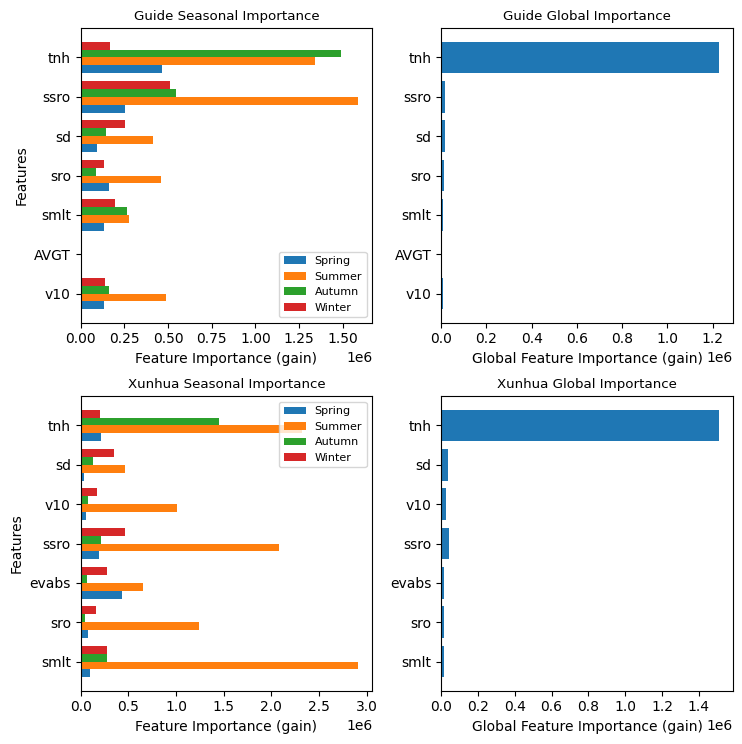

In [6]:
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(7.48, 7.48))
plt.rcParams.update({'font.size': 8})
for row, hydro_station in enumerate(hydro_stations):
    df = pd.read_csv(f'../data/{hydro_station.lower()}_vif_modeling_data_1960-2019.csv',parse_dates=['date'],index_col='date')
    df = df.rename(columns={'AVG-TEM(C)': 'AVGT'})
    samples,target,features = gen_one_out_samples(df,target_column='flow',mode='simulate',lags_dict=None,lag=12,lead=1)
    samples.to_csv(f'../samples/{hydro_station.lower()}_samples.csv')

    feature_samples = samples[features]
    feature_samples_ = feature_samples.loc[:'1986-01-01']

    target_samples = pd.DataFrame(samples[target],columns=[target])
    target_samples_ = target_samples.loc[:'1986-01-01']

    # Split features and target samples by season
    spring_feature_samples = feature_samples_[feature_samples_.index.month.isin([3,4,5])]
    summer_feature_samples = feature_samples_[feature_samples_.index.month.isin([6,7,8])]
    autumn_feature_samples = feature_samples_[feature_samples_.index.month.isin([9,10,11])]
    winter_feature_samples = feature_samples_[feature_samples_.index.month.isin([12,1,2])]

    spring_target_samples = target_samples_[target_samples_.index.month.isin([3,4,5])]
    summer_target_samples = target_samples_[target_samples_.index.month.isin([6,7,8])]
    autumn_target_samples = target_samples_[target_samples_.index.month.isin([9,10,11])]
    winter_target_samples = target_samples_[target_samples_.index.month.isin([12,1,2])]

    # Load trained XGBoost model
    model_path = f'../models/CER/{hydro_station.lower()}/XGBOOST_lag12/'
    model = load_model(model_path+f'vif_xgb_model.json')

    # Group features by base name (without lag)
    feature_groups = {}
    for feature in features:
        base_name = feature.split('_')[0]  # Get base name before lag
        if base_name not in feature_groups:
            feature_groups[base_name] = []
        feature_groups[base_name].append(feature)

    # Calculate seasonal and global feature importance using XGBoost gain
    seasonal_contributions = {
        'Spring': {},
        'Summer': {},
        'Autumn': {},
        'Winter': {}
    }
    global_contributions = {}

    # Get global feature importance
    global_importance = model.get_score(importance_type='gain')
    
    # Calculate aggregated importance for feature groups
    for base_name, feature_list in feature_groups.items():
        global_contributions[base_name] = sum(global_importance.get(f, 0) for f in feature_list)

    # Get seasonal predictions and importance using trained model
    for season, (X, y) in zip(
        ['Spring', 'Summer', 'Autumn', 'Winter'],
        [(spring_feature_samples, spring_target_samples),
         (summer_feature_samples, summer_target_samples),
         (autumn_feature_samples, autumn_target_samples),
         (winter_feature_samples, winter_target_samples)]
    ):
        # Use trained model to predict seasonal samples
        model_ = load_model(model_path+f'{season}_vif_xgb_model.json')
        seasonal_importance = model_.get_score(importance_type='gain')
        
        # Calculate aggregated importance for each feature group
        for base_name, feature_list in feature_groups.items():
            seasonal_contributions[season][base_name] = sum(seasonal_importance.get(f, 0) for f in feature_list)

    # Plot seasonal contributions horizontally
    features = list(feature_groups.keys())
    seasons = ['Spring', 'Summer', 'Autumn', 'Winter']
    y = np.arange(len(features))
    height = 0.2
    
    for i, season in enumerate(seasons):
        values = [seasonal_contributions[season][f] for f in features]
        axes[row,0].barh(y + i*height, values, height, label=season)

    axes[row,0].set_yticks(y + height*1.5)
    axes[row,0].set_yticklabels(features)
    axes[row,0].set_xlabel('Feature Importance (gain)')
    axes[row,0].set_ylabel('Features')
    axes[row,0].legend()
    axes[row,0].set_title(f'{hydro_station} Seasonal Importance')

    # Plot global contributions using same feature order as seasonal plot
    global_importance_df = pd.DataFrame({
        'Predictors': features,  # Use same feature order
        'Importance': [global_contributions[f] for f in features]
    })

    axes[row,1].barh(global_importance_df['Predictors'], global_importance_df['Importance'])
    axes[row,1].set_xlabel('Global Feature Importance (gain)')
    axes[row,1].set_title(f'{hydro_station} Global Importance')

fig.tight_layout()
plt.savefig(f'../figs/features_importance_XGB_comparison.tif', 
            format='TIFF', dpi=500, bbox_inches='tight')
plt.savefig(f'../figs/features_importance_XGB_comparison.png',
            format='PNG', dpi=600, bbox_inches='tight')
plt.show()


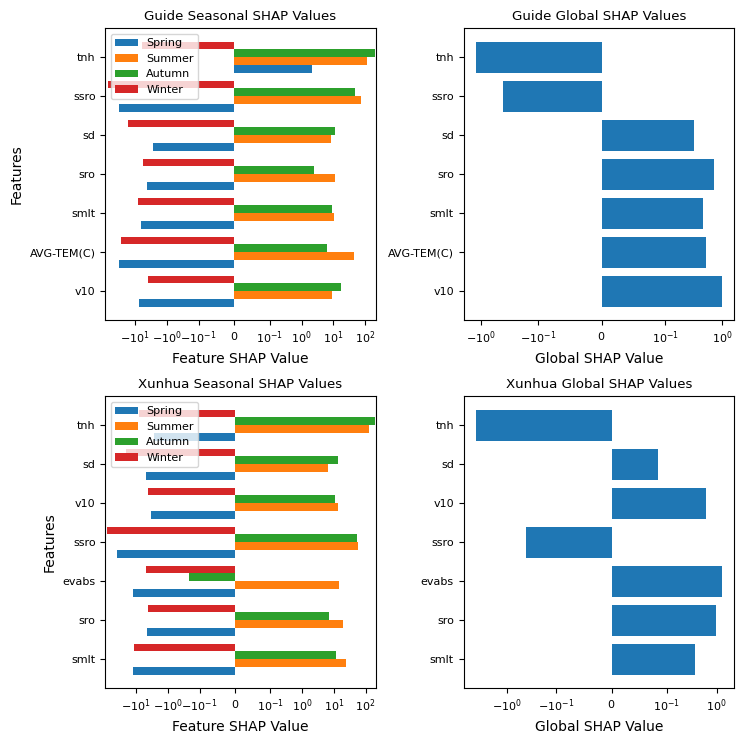

In [7]:
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import shap

# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(7.48, 7.48))
plt.rcParams.update({'font.size': 8})

for row, hydro_station in enumerate(hydro_stations):
    df = pd.read_csv(f'../data/{hydro_station.lower()}_vif_modeling_data_1960-2019.csv',parse_dates=['date'],index_col='date')
    
    samples,target,features = gen_one_out_samples(df,target_column='flow',mode='simulate',lags_dict=None,lag=12,lead=1)
    samples.to_csv(f'../samples/{hydro_station.lower()}_samples.csv')

    feature_samples = samples[features]
    feature_samples_ = feature_samples.loc[:'1986-01-01']

    target_samples = pd.DataFrame(samples[target],columns=[target])
    target_samples_ = target_samples.loc[:'1986-01-01']

    # Split features and target samples by season
    spring_feature_samples = feature_samples_[feature_samples_.index.month.isin([3,4,5])]
    summer_feature_samples = feature_samples_[feature_samples_.index.month.isin([6,7,8])]
    autumn_feature_samples = feature_samples_[feature_samples_.index.month.isin([9,10,11])]
    winter_feature_samples = feature_samples_[feature_samples_.index.month.isin([12,1,2])]

    spring_target_samples = target_samples_[target_samples_.index.month.isin([3,4,5])]
    summer_target_samples = target_samples_[target_samples_.index.month.isin([6,7,8])]
    autumn_target_samples = target_samples_[target_samples_.index.month.isin([9,10,11])]
    winter_target_samples = target_samples_[target_samples_.index.month.isin([12,1,2])]

    # Load trained XGBoost model
    model_path = f'../models/CER/{hydro_station.lower()}/XGBOOST_lag12/'
    model = load_model(model_path+f'vif_xgb_model.json')

    # Group features by base name (without lag)
    feature_groups = {}
    for feature in features:
        base_name = feature.split('_')[0]  # Get base name before lag
        if base_name not in feature_groups:
            feature_groups[base_name] = []
        feature_groups[base_name].append(feature)

    # Calculate SHAP values for global model
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(feature_samples_)
    
    # Calculate aggregated SHAP values for feature groups
    global_contributions = {}
    
    for base_name, feature_list in feature_groups.items():
        # Get indices of features in this group
        feature_indices = [features.index(f) for f in feature_list]
        
        # Sum SHAP values for all features in group
        group_shap = shap_values[:, feature_indices].sum(axis=1)
        global_contributions[base_name] = group_shap.mean()

    # Calculate seasonal SHAP values
    seasonal_contributions = {
        'Spring': {},
        'Summer': {},
        'Autumn': {},
        'Winter': {}
    }

    for season, X in zip(
        ['Spring', 'Summer', 'Autumn', 'Winter'],
        [spring_feature_samples, summer_feature_samples, 
         autumn_feature_samples, winter_feature_samples]
    ):
        # Load seasonal model
        model_path = f'../models/CER/{hydro_station.lower()}/XGBOOST_lag12/'
        model_ = load_model(model_path+f'{season}_vif_xgb_model.json')
        explainer_ = shap.TreeExplainer(model_)
        shap_values_ = explainer_.shap_values(X)
        
        for base_name, feature_list in feature_groups.items():
            feature_indices = [features.index(f) for f in feature_list]
            group_shap = shap_values_[:, feature_indices].sum(axis=1)
            seasonal_contributions[season][base_name] = group_shap.mean()

    # Plot seasonal contributions with symmetric log scale
    features = list(feature_groups.keys())
    seasons = ['Spring', 'Summer', 'Autumn', 'Winter']
    y = np.arange(len(features))
    height = 0.2
    
    for i, season in enumerate(seasons):
        values = [seasonal_contributions[season][f] for f in features]
        axes[row,0].barh(y + i*height, values, height, label=season)

    axes[row,0].set_yticks(y + height*1.5)
    axes[row,0].set_yticklabels(features)
    axes[row,0].set_xlabel('Feature SHAP Value', fontsize=ftsize)
    axes[row,0].set_ylabel('Features', fontsize=ftsize)
    axes[row,0].set_xscale('symlog', linthresh=0.1)  # Symmetric log scale
    axes[row,0].legend()
    axes[row,0].set_title(f'{hydro_station} Seasonal SHAP Values')

    # Plot global contributions
    global_importance_df = pd.DataFrame({
        'Predictors': features,
        'SHAP Values': [global_contributions[f] for f in features]
    })

    axes[row,1].barh(global_importance_df['Predictors'], global_importance_df['SHAP Values'])
    axes[row,1].set_xlabel('Global SHAP Value', fontsize=ftsize)
    axes[row,1].set_xscale('symlog', linthresh=0.1)  # Symmetric log scale
    axes[row,1].set_title(f'{hydro_station} Global SHAP Values')

fig.tight_layout()
plt.savefig(f'../figs/features_shap_XGB_comparison.tif', 
            format='TIFF', dpi=500, bbox_inches='tight')
plt.savefig(f'../figs/features_shap_XGB_comparison.png',
            format='PNG', dpi=600, bbox_inches='tight')
plt.show()

In [8]:
for hydro_station in hydro_stations:
    df = pd.read_csv(f'../data/{hydro_station.lower()}_vif_modeling_data_1960-2019.csv',parse_dates=['date'],index_col='date')
    # drop tnh_flow to build extension models
    df = df.drop(columns=['tnh_flow'])
    print(df)
    
    samples,target,features = gen_one_out_samples(df,target_column='flow',mode='simulate',lags_dict=None,lag=12,lead=1)
    samples.to_csv(f'../samples/{hydro_station.lower()}_samples.csv')

    feature_samples = samples[features]
    feature_samples_ = feature_samples.loc[:'1986-01-01']

    target_samples = pd.DataFrame(samples[target],columns=[target])
    target_samples_ = target_samples.loc[:'1986-01-01']

    model_path = f'../models/extension/{hydro_station.lower()}/XGBOOST_lag12/'
    if not os.path.exists(model_path):
        os.makedirs(model_path)
    if not os.path.exists(model_path+f'vif_xgb_model.json'):
        best_params = OptunaTuneMultioutXGBRegressorCV(
                    train_X=feature_samples_,
                    train_Y=target_samples_,
                    nfolds=nfolds,
                    n_trials=n_trials,#200
                    num_boost_round=num_boost_round,#100
                    n_warmup_steps=n_warmup_steps
        )   
        print(best_params)
        model = FitFinalMultioutXGBRegressor(feature_samples_,target_samples_,best_params,100)
        save_model(model,model_path+f'vif_xgb_model.json')
    else:
        model = load_model(model_path+f'vif_xgb_model.json')
    pred = predict(model,feature_samples)
    
    pred_df = pd.DataFrame(pred,columns=['E-XGB'],index=target_samples.index)
    pred_df.index.name = 'date'
    pred_df.to_csv(f'../results/xgb(Extension)_{hydro_station.lower()}.csv')


                 v10  AVG-TEM(C)      smlt       sro        sd      ssro  \
date                                                                       
1960-01-31  0.937511  -12.752986  0.000423  0.000062  0.020468  0.004090   
1960-02-29  0.527554   -8.002374  0.003312  0.000932  0.020473  0.003107   
1960-03-31  0.934352   -2.523280  0.010951  0.002701  0.019050  0.002482   
1960-04-30  0.094989    0.700331  0.020436  0.004004  0.015169  0.002131   
1960-05-31 -0.060234    6.175353  0.028711  0.005169  0.004706  0.001985   
...              ...         ...       ...       ...       ...       ...   
2019-08-31 -0.321948   11.461266  0.003087  0.003291  0.000122  0.014945   
2019-09-30 -0.219753    7.523939  0.021006  0.003460  0.002640  0.019583   
2019-10-31  0.254881    2.215784  0.013888  0.000760  0.006718  0.020596   
2019-11-30  0.746981   -3.226049  0.009707  0.000264  0.015395  0.014721   
2019-12-31  0.760826  -12.046475  0.001102  0.000027  0.016767  0.010785   

           

In [9]:
for hydro_station in hydro_stations:
    df = pd.read_csv(f'../results/xgb(Extension)_{hydro_station.lower()}.csv',parse_dates=['date'],index_col='date')
    flow = pd.read_csv(f'../data/{hydro_station.lower()}_vif_modeling_data_1960-2019.csv',parse_dates=['date'],index_col='date')


    cal_pred = df.loc['1961-01-01':'1981-12-31','E-XGB'].values
    cal_obs = flow.loc['1961-01-01':'1981-12-31','flow'].values


    print(cal_pred.shape)
    print(cal_obs.shape)
    
    # plt.plot(cal_obs)
    # plt.plot(cal_pred)
    # plt.show()

    test_pred = df.loc['1982-01-01':'1985-12-31','E-XGB'].values
    test_obs = flow.loc['1982-01-01':'1985-12-31','flow'].values
    print(cal_pred.shape[0]==cal_obs.shape[0])
    print(test_pred.shape[0]==test_obs.shape[0])

    metrics = pd.DataFrame(index=['cal','test'])
    metrics.index.name = 'period'
    metrics['ME'] = [he.me(observed_array=cal_obs, simulated_array=cal_pred),he.me(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MAE'] = [he.mae(observed_array=cal_obs, simulated_array=cal_pred),he.mae(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MSE'] = [he.mse(observed_array=cal_obs, simulated_array=cal_pred),he.mse(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MLE'] = [he.mle(observed_array=cal_obs, simulated_array=cal_pred),he.mle(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MALE'] = [he.male(observed_array=cal_obs, simulated_array=cal_pred),he.male(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MSLE'] = [he.msle(observed_array=cal_obs, simulated_array=cal_pred),he.msle(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MAPE'] = [he.mape(observed_array=cal_obs, simulated_array=cal_pred),he.mape(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MDE'] = [he.mde(observed_array=cal_obs, simulated_array=cal_pred),he.mde(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MDAE'] = [he.mdae(observed_array=cal_obs, simulated_array=cal_pred),he.mdae(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MDSE'] = [he.mdse(observed_array=cal_obs, simulated_array=cal_pred),he.mdse(observed_array=test_obs, simulated_array=test_pred),]
    metrics['ED'] = [he.ed(observed_array=cal_obs, simulated_array=cal_pred),he.ed(observed_array=test_obs, simulated_array=test_pred),]
    metrics['NED'] = [he.ned(observed_array=cal_obs, simulated_array=cal_pred),he.ned(observed_array=test_obs, simulated_array=test_pred),]
    metrics['RMSE'] = [he.rmse(observed_array=cal_obs, simulated_array=cal_pred), he.rmse(observed_array=test_obs, simulated_array=test_pred),]
    metrics['RMSLE'] = [he.rmsle(observed_array=cal_obs, simulated_array=cal_pred), he.rmsle(observed_array=test_obs, simulated_array=test_pred),]
    metrics['NRMSE_RANGE'] = [he.nrmse_range(observed_array=cal_obs, simulated_array=cal_pred), he.nrmse_range(observed_array=test_obs, simulated_array=test_pred),]
    metrics['NRMSE_MEAN'] = [he.nrmse_mean(observed_array=cal_obs, simulated_array=cal_pred), he.nrmse_mean(observed_array=test_obs, simulated_array=test_pred),]
    metrics['NRMSE_IQR'] = [he.nrmse_iqr(observed_array=cal_obs, simulated_array=cal_pred), he.nrmse_iqr(observed_array=test_obs, simulated_array=test_pred),]
    metrics['IRMSE'] = [he.irmse(observed_array=cal_obs, simulated_array=cal_pred), he.irmse(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MASE'] = [he.mase(observed_array=cal_obs, simulated_array=cal_pred), he.mase(observed_array=test_obs, simulated_array=test_pred),]
    metrics['R_SQUARED'] = [he.r_squared(observed_array=cal_obs, simulated_array=cal_pred), he.r_squared(observed_array=test_obs, simulated_array=test_pred),]
    metrics['PEARSON_R'] = [he.pearson_r(observed_array=cal_obs, simulated_array=cal_pred), he.pearson_r(observed_array=test_obs, simulated_array=test_pred),]
    metrics['SPEARMAN_R'] = [he.spearman_r(observed_array=cal_obs, simulated_array=cal_pred), he.spearman_r(observed_array=test_obs, simulated_array=test_pred),]
    metrics['ACC'] = [he.acc(observed_array=cal_obs, simulated_array=cal_pred), he.acc(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MAPE'] = [he.mape(observed_array=cal_obs, simulated_array=cal_pred), he.mape(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MAPD'] = [he.mapd(observed_array=cal_obs, simulated_array=cal_pred), he.mapd(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MAAPE'] = [he.maape(observed_array=cal_obs, simulated_array=cal_pred), he.maape(observed_array=test_obs, simulated_array=test_pred),]
    metrics['SMAPE1'] = [he.smape1(observed_array=cal_obs, simulated_array=cal_pred), he.smape1(observed_array=test_obs, simulated_array=test_pred),]
    metrics['SMAPE2'] = [he.smape2(observed_array=cal_obs, simulated_array=cal_pred), he.smape2(observed_array=test_obs, simulated_array=test_pred),]
    metrics['D'] = [he.d(observed_array=cal_obs, simulated_array=cal_pred), he.d(observed_array=test_obs, simulated_array=test_pred),]
    metrics['D1'] = [he.d1(observed_array=cal_obs, simulated_array=cal_pred), he.d1(observed_array=test_obs, simulated_array=test_pred),]
    metrics['DMOD'] = [he.dmod(observed_array=cal_obs, simulated_array=cal_pred), he.dmod(observed_array=test_obs, simulated_array=test_pred),]
    metrics['DREL'] = [he.drel(observed_array=cal_obs, simulated_array=cal_pred), he.drel(observed_array=test_obs, simulated_array=test_pred),]
    metrics['DR'] = [he.dr(observed_array=cal_obs, simulated_array=cal_pred), he.dr(observed_array=test_obs, simulated_array=test_pred),]
    metrics['WATT_M'] = [he.watt_m(observed_array=cal_obs, simulated_array=cal_pred), he.watt_m(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MB_R'] = [he.mb_r(observed_array=cal_obs, simulated_array=cal_pred), he.mb_r(observed_array=test_obs, simulated_array=test_pred),]
    metrics['NSE'] = [he.nse(observed_array=cal_obs, simulated_array=cal_pred), he.nse(observed_array=test_obs, simulated_array=test_pred),]
    metrics['NSE_MOD'] = [he.nse_mod(observed_array=cal_obs, simulated_array=cal_pred), he.nse_mod(observed_array=test_obs, simulated_array=test_pred),]
    metrics['NSE_REL'] = [he.nse_rel(observed_array=cal_obs, simulated_array=cal_pred), he.nse_rel(observed_array=test_obs, simulated_array=test_pred),]
    metrics['KGE_2009'] = [he.kge_2009(observed_array=cal_obs, simulated_array=cal_pred),he.kge_2009(observed_array=test_obs, simulated_array=test_pred),]
    metrics['KGE_2012'] = [he.kge_2012(observed_array=cal_obs, simulated_array=cal_pred),he.kge_2012(observed_array=test_obs, simulated_array=test_pred),]
    metrics['LM_INDEX'] = [he.lm_index(observed_array=cal_obs, simulated_array=cal_pred),he.lm_index(observed_array=test_obs, simulated_array=test_pred),]
    metrics['D1_P'] = [he.d1_p(observed_array=cal_obs, simulated_array=cal_pred),he.d1_p(observed_array=test_obs, simulated_array=test_pred),]
    metrics['VE'] = [he.ve(observed_array=cal_obs, simulated_array=cal_pred),he.ve(observed_array=test_obs, simulated_array=test_pred),]
    metrics['SA'] = [he.sa(observed_array=cal_obs, simulated_array=cal_pred),he.sa(observed_array=test_obs, simulated_array=test_pred),]
    metrics['SC'] = [he.sc(observed_array=cal_obs, simulated_array=cal_pred),he.sc(observed_array=test_obs, simulated_array=test_pred),]
    metrics['SID'] = [he.sid(observed_array=cal_obs, simulated_array=cal_pred),he.sid(observed_array=test_obs, simulated_array=test_pred),]
    metrics['SGA'] = [he.sga(observed_array=cal_obs, simulated_array=cal_pred),he.sga(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H1_MHE'] = [he.h1_mhe(observed_array=cal_obs, simulated_array=cal_pred),he.h1_mhe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H1_MAHE'] = [he.h1_mahe(observed_array=cal_obs, simulated_array=cal_pred),he.h1_mahe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H1_RMSHE'] = [he.h1_rmshe(observed_array=cal_obs, simulated_array=cal_pred),he.h1_rmshe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H2_MHE'] = [he.h2_mhe(observed_array=cal_obs, simulated_array=cal_pred),he.h2_mhe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H2_MAHE'] = [he.h2_mahe(observed_array=cal_obs, simulated_array=cal_pred),he.h2_mahe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H2_RMSHE'] = [he.h2_rmshe(observed_array=cal_obs, simulated_array=cal_pred),he.h2_rmshe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H3_MHE'] = [he.h3_mhe(observed_array=cal_obs, simulated_array=cal_pred),he.h3_mhe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H3_MAHE'] = [he.h3_mahe(observed_array=cal_obs, simulated_array=cal_pred),he.h3_mahe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H3_RMSHE'] = [he.h3_rmshe(observed_array=cal_obs, simulated_array=cal_pred),he.h3_rmshe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H4_MHE'] = [he.h4_mhe(observed_array=cal_obs, simulated_array=cal_pred),he.h4_mhe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H4_MAHE'] = [he.h4_mahe(observed_array=cal_obs, simulated_array=cal_pred),he.h4_mahe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H4_RMSHE'] = [he.h4_rmshe(observed_array=cal_obs, simulated_array=cal_pred),he.h4_rmshe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H5_MHE'] = [he.h5_mhe(observed_array=cal_obs, simulated_array=cal_pred),he.h5_mhe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H5_MAHE'] = [he.h5_mahe(observed_array=cal_obs, simulated_array=cal_pred),he.h5_mahe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H5_RMSHE'] = [he.h5_rmshe(observed_array=cal_obs, simulated_array=cal_pred),he.h5_rmshe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H6_MHE'] = [he.h6_mhe(observed_array=cal_obs, simulated_array=cal_pred),he.h6_mhe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H6_MAHE'] = [he.h6_mahe(observed_array=cal_obs, simulated_array=cal_pred),he.h6_mahe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H6_RMSHE'] = [he.h6_rmshe(observed_array=cal_obs, simulated_array=cal_pred),he.h6_rmshe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H7_MHE'] = [he.h7_mhe(observed_array=cal_obs, simulated_array=cal_pred),he.h7_mhe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H7_MAHE'] = [he.h7_mahe(observed_array=cal_obs, simulated_array=cal_pred),he.h7_mahe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H7_RMSHE'] = [he.h7_rmshe(observed_array=cal_obs, simulated_array=cal_pred),he.h7_rmshe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H8_MHE'] = [he.h8_mhe(observed_array=cal_obs, simulated_array=cal_pred),he.h8_mhe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H8_MAHE'] = [he.h8_mahe(observed_array=cal_obs, simulated_array=cal_pred),he.h8_mahe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H8_RMSHE'] = [he.h8_rmshe(observed_array=cal_obs, simulated_array=cal_pred),he.h8_rmshe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H10_MHE'] = [he.h10_mhe(observed_array=cal_obs, simulated_array=cal_pred),he.h10_mhe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H10_MAHE'] = [he.h10_mahe(observed_array=cal_obs, simulated_array=cal_pred),he.h10_mahe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H10_RMSHE'] = [he.h10_rmshe(observed_array=cal_obs, simulated_array=cal_pred),he.h10_rmshe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['G_MEAN_DIFF'] = [he.g_mean_diff(observed_array=cal_obs, simulated_array=cal_pred),he.g_mean_diff(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MEAN_VAR'] = [he.mean_var(observed_array=cal_obs, simulated_array=cal_pred),he.mean_var(observed_array=test_obs, simulated_array=test_pred),]
    metrics['PPMAE'] = [PPMAE(y_true=cal_obs,y_pred=cal_pred),PPMAE(y_true=test_obs,y_pred=test_pred),]
    metrics['LPMAE'] = [LPMAE(y_true=cal_obs,y_pred=cal_pred),LPMAE(y_true=test_obs,y_pred=test_pred),]

    metrics.to_csv(f'../results/xgb(Extension)_metrics_{hydro_station.lower()}.csv')
    # metrics['R2'] = [round(R2(cal_obs, cal_pred),4), round(R2(test_obs, test_pred),4)]
    print(hydro_station,'\n',metrics)

(252,)
(252,)
True
True
Guide 
               ME       MAE          MSE       MLE      MALE      MSLE  \
period                                                                  
cal    -0.103531  5.830371  1023.444567  0.001532  0.005564  0.000229   
test    0.203775  3.969117    71.906763  0.000409  0.004608  0.000063   

            MAPE       MDE      MDAE      MDSE  ...    H8_MHE   H8_MAHE  \
period                                          ...                       
cal     0.559538  0.111099  0.938046  0.879933  ...  0.001455  0.004929   
test    0.462836 -0.390962  1.366342  1.894209  ...  0.000429  0.004495   

        H8_RMSHE   H10_MHE  H10_MAHE  H10_RMSHE  G_MEAN_DIFF  MEAN_VAR  \
period                                                                   
cal     0.013334  0.001532  0.005564   0.015132     1.001638  0.000227   
test    0.007766  0.000409  0.004608   0.007935     1.000410  0.000063   

            PPMAE     LPMAE  
period                       
cal     45.478562

In [10]:
for hydro_station in hydro_stations:
    df = pd.read_csv(f'../data/{hydro_station.lower()}_vif_modeling_data_1960-2019.csv',parse_dates=['date'],index_col='date')
    # select data before 1986

    # preserve tnh_flow and flow
    df = df[['tnh_flow','flow']]
    
    samples,target,features = gen_one_out_samples(df,target_column='flow',mode='simulate',lags_dict=None,lag=12,lead=1)
    samples.to_csv(f'../samples/{hydro_station.lower()}_samples.csv')

    feature_samples = samples[features]
    feature_samples_ = feature_samples.loc[:'1986-01-01']

    target_samples = pd.DataFrame(samples[target],columns=[target])
    target_samples_ = target_samples.loc[:'1986-01-01']

    model_path = f'../models/Routing/{hydro_station.lower()}/XGBOOST_lag12/'
    if not os.path.exists(model_path):
        os.makedirs(model_path)

    if not os.path.exists(model_path+f'vif_xgb_model.json'):
        best_params = OptunaTuneMultioutXGBRegressorCV(
                    train_X=feature_samples_,
                    train_Y=target_samples_,
                    nfolds=nfolds,
                    n_trials=n_trials,#200
                    num_boost_round=num_boost_round,#100
                n_warmup_steps=n_warmup_steps
        )   
        print(best_params)
        model = FitFinalMultioutXGBRegressor(feature_samples_,target_samples_,best_params,100)
        save_model(model,model_path+f'vif_xgb_model.json')
    else:
        model = load_model(model_path+f'vif_xgb_model.json')
    pred = predict(model,feature_samples)
    
    pred_df = pd.DataFrame(pred,columns=['R-XGB'],index=target_samples.index)
    pred_df.index.name = 'date'
    pred_df.to_csv(f'../results/xgb(Routing)_{hydro_station.lower()}.csv')
    

In [11]:
for hydro_station in hydro_stations:
    df = pd.read_csv(f'../results/xgb(Routing)_{hydro_station.lower()}.csv',parse_dates=['date'],index_col='date')
    flow = pd.read_csv(f'../data/{hydro_station.lower()}_vif_modeling_data_1960-2019.csv',parse_dates=['date'],index_col='date')


    cal_pred = df.loc['1961-01-01':'1981-12-31','R-XGB'].values
    cal_obs = flow.loc['1961-01-01':'1981-12-31','flow'].values

    # print(cal_pred.shape)
    # print(cal_obs.shape)
    
    # plt.plot(cal_obs)
    # plt.plot(cal_pred)
    # plt.show()

    test_pred = df.loc['1982-01-01':'1985-12-31','R-XGB'].values
    test_obs = flow.loc['1982-01-01':'1985-12-31','flow'].values

    metrics = pd.DataFrame(index=['cal','test'])
    metrics.index.name = 'period'
    metrics['ME'] = [he.me(observed_array=cal_obs, simulated_array=cal_pred),he.me(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MAE'] = [he.mae(observed_array=cal_obs, simulated_array=cal_pred),he.mae(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MSE'] = [he.mse(observed_array=cal_obs, simulated_array=cal_pred),he.mse(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MLE'] = [he.mle(observed_array=cal_obs, simulated_array=cal_pred),he.mle(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MALE'] = [he.male(observed_array=cal_obs, simulated_array=cal_pred),he.male(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MSLE'] = [he.msle(observed_array=cal_obs, simulated_array=cal_pred),he.msle(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MAPE'] = [he.mape(observed_array=cal_obs, simulated_array=cal_pred),he.mape(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MDE'] = [he.mde(observed_array=cal_obs, simulated_array=cal_pred),he.mde(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MDAE'] = [he.mdae(observed_array=cal_obs, simulated_array=cal_pred),he.mdae(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MDSE'] = [he.mdse(observed_array=cal_obs, simulated_array=cal_pred),he.mdse(observed_array=test_obs, simulated_array=test_pred),]
    metrics['ED'] = [he.ed(observed_array=cal_obs, simulated_array=cal_pred),he.ed(observed_array=test_obs, simulated_array=test_pred),]
    metrics['NED'] = [he.ned(observed_array=cal_obs, simulated_array=cal_pred),he.ned(observed_array=test_obs, simulated_array=test_pred),]
    metrics['RMSE'] = [he.rmse(observed_array=cal_obs, simulated_array=cal_pred), he.rmse(observed_array=test_obs, simulated_array=test_pred),]
    metrics['RMSLE'] = [he.rmsle(observed_array=cal_obs, simulated_array=cal_pred), he.rmsle(observed_array=test_obs, simulated_array=test_pred),]
    metrics['NRMSE_RANGE'] = [he.nrmse_range(observed_array=cal_obs, simulated_array=cal_pred), he.nrmse_range(observed_array=test_obs, simulated_array=test_pred),]
    metrics['NRMSE_MEAN'] = [he.nrmse_mean(observed_array=cal_obs, simulated_array=cal_pred), he.nrmse_mean(observed_array=test_obs, simulated_array=test_pred),]
    metrics['NRMSE_IQR'] = [he.nrmse_iqr(observed_array=cal_obs, simulated_array=cal_pred), he.nrmse_iqr(observed_array=test_obs, simulated_array=test_pred),]
    metrics['IRMSE'] = [he.irmse(observed_array=cal_obs, simulated_array=cal_pred), he.irmse(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MASE'] = [he.mase(observed_array=cal_obs, simulated_array=cal_pred), he.mase(observed_array=test_obs, simulated_array=test_pred),]
    metrics['R_SQUARED'] = [he.r_squared(observed_array=cal_obs, simulated_array=cal_pred), he.r_squared(observed_array=test_obs, simulated_array=test_pred),]
    metrics['PEARSON_R'] = [he.pearson_r(observed_array=cal_obs, simulated_array=cal_pred), he.pearson_r(observed_array=test_obs, simulated_array=test_pred),]
    metrics['SPEARMAN_R'] = [he.spearman_r(observed_array=cal_obs, simulated_array=cal_pred), he.spearman_r(observed_array=test_obs, simulated_array=test_pred),]
    metrics['ACC'] = [he.acc(observed_array=cal_obs, simulated_array=cal_pred), he.acc(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MAPE'] = [he.mape(observed_array=cal_obs, simulated_array=cal_pred), he.mape(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MAPD'] = [he.mapd(observed_array=cal_obs, simulated_array=cal_pred), he.mapd(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MAAPE'] = [he.maape(observed_array=cal_obs, simulated_array=cal_pred), he.maape(observed_array=test_obs, simulated_array=test_pred),]
    metrics['SMAPE1'] = [he.smape1(observed_array=cal_obs, simulated_array=cal_pred), he.smape1(observed_array=test_obs, simulated_array=test_pred),]
    metrics['SMAPE2'] = [he.smape2(observed_array=cal_obs, simulated_array=cal_pred), he.smape2(observed_array=test_obs, simulated_array=test_pred),]
    metrics['D'] = [he.d(observed_array=cal_obs, simulated_array=cal_pred), he.d(observed_array=test_obs, simulated_array=test_pred),]
    metrics['D1'] = [he.d1(observed_array=cal_obs, simulated_array=cal_pred), he.d1(observed_array=test_obs, simulated_array=test_pred),]
    metrics['DMOD'] = [he.dmod(observed_array=cal_obs, simulated_array=cal_pred), he.dmod(observed_array=test_obs, simulated_array=test_pred),]
    metrics['DREL'] = [he.drel(observed_array=cal_obs, simulated_array=cal_pred), he.drel(observed_array=test_obs, simulated_array=test_pred),]
    metrics['DR'] = [he.dr(observed_array=cal_obs, simulated_array=cal_pred), he.dr(observed_array=test_obs, simulated_array=test_pred),]
    metrics['WATT_M'] = [he.watt_m(observed_array=cal_obs, simulated_array=cal_pred), he.watt_m(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MB_R'] = [he.mb_r(observed_array=cal_obs, simulated_array=cal_pred), he.mb_r(observed_array=test_obs, simulated_array=test_pred),]
    metrics['NSE'] = [he.nse(observed_array=cal_obs, simulated_array=cal_pred), he.nse(observed_array=test_obs, simulated_array=test_pred),]
    metrics['NSE_MOD'] = [he.nse_mod(observed_array=cal_obs, simulated_array=cal_pred), he.nse_mod(observed_array=test_obs, simulated_array=test_pred),]
    metrics['NSE_REL'] = [he.nse_rel(observed_array=cal_obs, simulated_array=cal_pred), he.nse_rel(observed_array=test_obs, simulated_array=test_pred),]
    metrics['KGE_2009'] = [he.kge_2009(observed_array=cal_obs, simulated_array=cal_pred),he.kge_2009(observed_array=test_obs, simulated_array=test_pred),]
    metrics['KGE_2012'] = [he.kge_2012(observed_array=cal_obs, simulated_array=cal_pred),he.kge_2012(observed_array=test_obs, simulated_array=test_pred),]
    metrics['LM_INDEX'] = [he.lm_index(observed_array=cal_obs, simulated_array=cal_pred),he.lm_index(observed_array=test_obs, simulated_array=test_pred),]
    metrics['D1_P'] = [he.d1_p(observed_array=cal_obs, simulated_array=cal_pred),he.d1_p(observed_array=test_obs, simulated_array=test_pred),]
    metrics['VE'] = [he.ve(observed_array=cal_obs, simulated_array=cal_pred),he.ve(observed_array=test_obs, simulated_array=test_pred),]
    metrics['SA'] = [he.sa(observed_array=cal_obs, simulated_array=cal_pred),he.sa(observed_array=test_obs, simulated_array=test_pred),]
    metrics['SC'] = [he.sc(observed_array=cal_obs, simulated_array=cal_pred),he.sc(observed_array=test_obs, simulated_array=test_pred),]
    metrics['SID'] = [he.sid(observed_array=cal_obs, simulated_array=cal_pred),he.sid(observed_array=test_obs, simulated_array=test_pred),]
    metrics['SGA'] = [he.sga(observed_array=cal_obs, simulated_array=cal_pred),he.sga(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H1_MHE'] = [he.h1_mhe(observed_array=cal_obs, simulated_array=cal_pred),he.h1_mhe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H1_MAHE'] = [he.h1_mahe(observed_array=cal_obs, simulated_array=cal_pred),he.h1_mahe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H1_RMSHE'] = [he.h1_rmshe(observed_array=cal_obs, simulated_array=cal_pred),he.h1_rmshe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H2_MHE'] = [he.h2_mhe(observed_array=cal_obs, simulated_array=cal_pred),he.h2_mhe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H2_MAHE'] = [he.h2_mahe(observed_array=cal_obs, simulated_array=cal_pred),he.h2_mahe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H2_RMSHE'] = [he.h2_rmshe(observed_array=cal_obs, simulated_array=cal_pred),he.h2_rmshe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H3_MHE'] = [he.h3_mhe(observed_array=cal_obs, simulated_array=cal_pred),he.h3_mhe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H3_MAHE'] = [he.h3_mahe(observed_array=cal_obs, simulated_array=cal_pred),he.h3_mahe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H3_RMSHE'] = [he.h3_rmshe(observed_array=cal_obs, simulated_array=cal_pred),he.h3_rmshe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H4_MHE'] = [he.h4_mhe(observed_array=cal_obs, simulated_array=cal_pred),he.h4_mhe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H4_MAHE'] = [he.h4_mahe(observed_array=cal_obs, simulated_array=cal_pred),he.h4_mahe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H4_RMSHE'] = [he.h4_rmshe(observed_array=cal_obs, simulated_array=cal_pred),he.h4_rmshe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H5_MHE'] = [he.h5_mhe(observed_array=cal_obs, simulated_array=cal_pred),he.h5_mhe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H5_MAHE'] = [he.h5_mahe(observed_array=cal_obs, simulated_array=cal_pred),he.h5_mahe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H5_RMSHE'] = [he.h5_rmshe(observed_array=cal_obs, simulated_array=cal_pred),he.h5_rmshe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H6_MHE'] = [he.h6_mhe(observed_array=cal_obs, simulated_array=cal_pred),he.h6_mhe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H6_MAHE'] = [he.h6_mahe(observed_array=cal_obs, simulated_array=cal_pred),he.h6_mahe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H6_RMSHE'] = [he.h6_rmshe(observed_array=cal_obs, simulated_array=cal_pred),he.h6_rmshe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H7_MHE'] = [he.h7_mhe(observed_array=cal_obs, simulated_array=cal_pred),he.h7_mhe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H7_MAHE'] = [he.h7_mahe(observed_array=cal_obs, simulated_array=cal_pred),he.h7_mahe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H7_RMSHE'] = [he.h7_rmshe(observed_array=cal_obs, simulated_array=cal_pred),he.h7_rmshe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H8_MHE'] = [he.h8_mhe(observed_array=cal_obs, simulated_array=cal_pred),he.h8_mhe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H8_MAHE'] = [he.h8_mahe(observed_array=cal_obs, simulated_array=cal_pred),he.h8_mahe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H8_RMSHE'] = [he.h8_rmshe(observed_array=cal_obs, simulated_array=cal_pred),he.h8_rmshe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H10_MHE'] = [he.h10_mhe(observed_array=cal_obs, simulated_array=cal_pred),he.h10_mhe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H10_MAHE'] = [he.h10_mahe(observed_array=cal_obs, simulated_array=cal_pred),he.h10_mahe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['H10_RMSHE'] = [he.h10_rmshe(observed_array=cal_obs, simulated_array=cal_pred),he.h10_rmshe(observed_array=test_obs, simulated_array=test_pred),]
    metrics['G_MEAN_DIFF'] = [he.g_mean_diff(observed_array=cal_obs, simulated_array=cal_pred),he.g_mean_diff(observed_array=test_obs, simulated_array=test_pred),]
    metrics['MEAN_VAR'] = [he.mean_var(observed_array=cal_obs, simulated_array=cal_pred),he.mean_var(observed_array=test_obs, simulated_array=test_pred),]
    metrics['PPMAE'] = [PPMAE(y_true=cal_obs,y_pred=cal_pred),PPMAE(y_true=test_obs,y_pred=test_pred),]
    metrics['LPMAE'] = [LPMAE(y_true=cal_obs,y_pred=cal_pred),LPMAE(y_true=test_obs,y_pred=test_pred),]
    metrics.to_csv(f'../results/xgb(Routing)_metrics_{hydro_station.lower()}.csv')
    print(hydro_station,'\n',metrics)

Guide 
               ME       MAE          MSE       MLE      MALE      MSLE  \
period                                                                  
cal    -0.544004  9.302831  2629.288484  0.001641  0.009892  0.000483   
test   -2.058949  8.511782   285.166759 -0.003376  0.011105  0.000492   

            MAPE       MDE      MDAE      MDSE  ...    H8_MHE   H8_MAHE  \
period                                          ...                       
cal     0.986762  0.246103  2.407272  5.795013  ...  0.001733  0.009090   
test    1.097955 -0.740927  3.016989  9.208443  ... -0.003015  0.010525   

        H8_RMSHE   H10_MHE  H10_MAHE  H10_RMSHE  G_MEAN_DIFF  MEAN_VAR  \
period                                                                   
cal     0.019273  0.001641  0.009892   0.021984     1.001809  0.000481   
test    0.020493 -0.003376  0.011105   0.022183     0.996362  0.000481   

            PPMAE     LPMAE  
period                       
cal     98.012413  2.238491  
test    40.